In [17]:
import pandas as pd
titanic_df = pd.read_csv('final_titanic_data.csv')
titanic_df.head()

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,0,22.0,1.0,0.0,7.2500,0,3,0,1,0
1,1,38.0,1.0,0.0,71.2833,1,1,1,0,1
2,1,26.0,0.0,0.0,7.9250,0,3,1,0,0
3,1,35.0,1.0,0.0,53.1000,1,1,1,0,0
4,0,35.0,0.0,0.0,8.0500,0,3,0,1,0


### Handling Data Normalization

1. Min-Max Normalization

In [18]:
min_fare = titanic_df.Fare.min()
max_fare = titanic_df.Fare.max()


In [19]:
norm_fare = (titanic_df.Fare - min_fare) / (max_fare - min_fare)
norm_fare

0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
831    0.025374
832    0.058556
833    0.045771
834    0.058556
835    0.015127
Name: Fare, Length: 836, dtype: float64

In [20]:
norm_fare.describe()

count    836.000000
mean       0.061442
std        0.097178
min        0.000000
25%        0.015412
50%        0.026635
75%        0.058694
max        1.000000
Name: Fare, dtype: float64

In [21]:
# titanic_df['Fare_Normalized'] = (
#     titanic_df['Fare'] - min_fare
# ) / (
#     max_fare - min_fare
# )

# titanic_df[['Fare', 'Fare_Normalized']].head()

<Axes: ylabel='Density'>

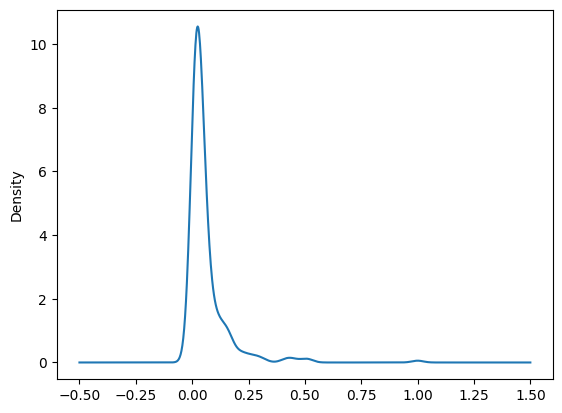

In [22]:
norm_fare.plot(kind='kde')

In [23]:
from sklearn.preprocessing import MinMaxScaler

In [24]:
mm_scaler = MinMaxScaler()

scaled_data = mm_scaler.fit_transform(titanic_df)

In [25]:
pd.DataFrame(scaled_data, columns=titanic_df.columns)

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,0.0,0.377358,0.125,0.000000,0.014151,0.0,1.0,0.0,1.0,0.0
1,1.0,0.679245,0.125,0.000000,0.139136,1.0,0.0,1.0,0.0,0.5
2,1.0,0.452830,0.000,0.000000,0.015469,0.0,1.0,1.0,0.0,0.0
3,1.0,0.622642,0.125,0.000000,0.103644,1.0,0.0,1.0,0.0,0.0
4,0.0,0.622642,0.000,0.000000,0.015713,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
831,0.0,0.471698,0.000,0.000000,0.025374,0.0,0.5,0.0,1.0,0.0
832,1.0,0.320755,0.000,0.000000,0.058556,1.0,0.0,1.0,0.0,0.0
833,0.0,0.367925,0.125,0.333333,0.045771,0.0,1.0,1.0,0.0,0.0
834,1.0,0.452830,0.000,0.000000,0.058556,1.0,0.0,0.0,1.0,0.5


2. Z-Score Normalization / StandardScaler

In [ ]:
mean_fare = titanic_df.Fare.mean()
std = titanic_df.Fare.std()

In [27]:
scaled_fare = (titanic_df.Fare - mean_fare) / std

In [30]:
round(scaled_fare.describe(), 7)

count    836.000000
mean      -0.000000
std        1.000000
min       -0.632255
25%       -0.473664
50%       -0.358172
75%       -0.028270
max        9.658101
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

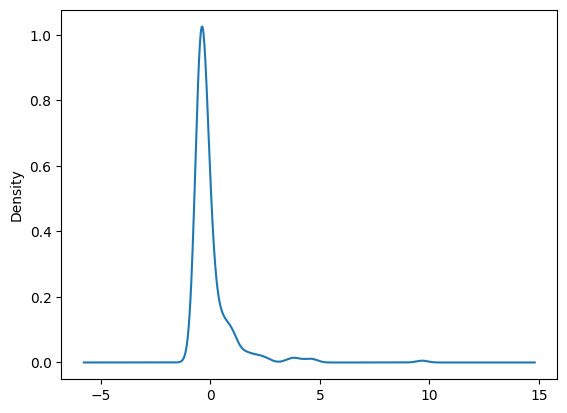

In [31]:
scaled_fare.plot(kind = 'kde')

In [32]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
norm_data = std_scaler.fit_transform(titanic_df)

In [33]:
pd.DataFrame(norm_data, columns=titanic_df.columns)

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,-0.781531,-0.578241,0.426663,-0.459888,-0.486927,-0.521968,0.797510,-0.748132,0.748132,-0.562417
1,1.279541,0.893886,0.426663,-0.459888,0.799980,1.915826,-1.635768,1.336663,-1.336663,1.004852
2,1.279541,-0.210210,-0.474070,-0.459888,-0.473361,-0.521968,0.797510,1.336663,-1.336663,-0.562417
3,1.279541,0.617862,0.426663,-0.459888,0.434542,1.915826,-1.635768,1.336663,-1.336663,-0.562417
4,-0.781531,0.617862,-0.474070,-0.459888,-0.470849,-0.521968,0.797510,-0.748132,0.748132,-0.562417
...,...,...,...,...,...,...,...,...,...,...
831,-0.781531,-0.118202,-0.474070,-0.459888,-0.371367,-0.521968,-0.419129,-0.748132,0.748132,-0.562417
832,1.279541,-0.854265,-0.474070,-0.459888,-0.029710,1.915826,-1.635768,1.336663,-1.336663,-0.562417
833,-0.781531,-0.624245,0.426663,2.036647,-0.161348,-0.521968,0.797510,1.336663,-1.336663,-0.562417
834,1.279541,-0.210210,-0.474070,-0.459888,-0.029710,1.915826,-1.635768,-0.748132,0.748132,1.004852
